<>:282: SyntaxWarning: invalid escape sequence '\i'
<>:282: SyntaxWarning: invalid escape sequence '\i'
/var/folders/kp/0cqs6yg572jgfkspzdc39y6r0000gn/T/ipykernel_59780/713732866.py:282: SyntaxWarning: invalid escape sequence '\i'
  axes.set_ylabel('log($N(t)-N(\infty)$)') # 指数增长


构建系统算符...
初始态信息:
  叠加系数: α=1.0, β=1.0
  真空态分量: 0.0000
  单粒子态分量: 0.0000
开始直接数值求解...
求解完成


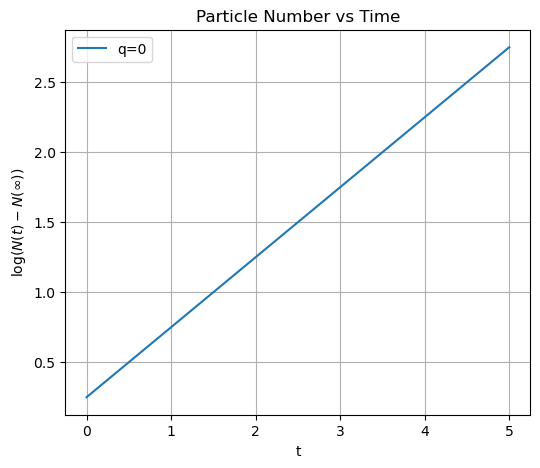


系统参数: L=4, J=1, γ=2
初始总粒子数: 4.0000
最终总粒子数: 0.3636


In [33]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from scipy.optimize import curve_fit


# 工具函数
def tensor_product(matrices):
    """计算多个矩阵的张量积"""
    return reduce(np.kron, matrices)

def annihilation_operator(N, site):
    """
    构造N格点系统中第site个格点的湮灭算符
    
    参数:
        N: 格点总数
        site: 格点索引 (0-based)
    
    返回:
        a_i: 2^N × 2^N 矩阵
    """
    # Jordan-Wigner变换因子
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # 构造弦算符 (site之前的所有格点)
    operators = []
    for j in range(N):
        if j < site:
            operators.append(sigma_z)  # 弦算符部分
        elif j == site:
            operators.append(np.array([[0, 1], [0, 0]]))  # 湮灭算符
        else:
            operators.append(np.eye(2))  # 单位矩阵
    
    # 计算Kronecker积
    result = operators[0]
    for op in operators[1:]:
        result = np.kron(result, op)
    
    return result

def creation_operator(N, site):
    """
    构造N格点系统中第site个格点的产生算符
    """
    return annihilation_operator(N, site).conj().T

def number_operator(N, site):
    """
    构造占据数算符 n_i = a_i† a_i
    """
    a = annihilation_operator(N, site)
    a_dag = creation_operator(N, site)
    return a_dag @ a

def build_hamiltonian(L, J):
    """构建最近邻跃迁哈密顿量"""
    H = np.eye(2**L, dtype=complex)
    for i in range(L-1):
        H_hop = -J *(creation_operator(L, i) @ annihilation_operator(L, i+1) + creation_operator(L, i+1) @ annihilation_operator(L, i))
        H += H_hop
    
    H += -J *(creation_operator(L, L-1) @ annihilation_operator(L, 0) + creation_operator(L, 0) @ annihilation_operator(L, L-1))
    return H

def build_lindblad_operators(L, gamma):
    """构建单向跃迁Lindblad算符"""
    lindblad_ops = []
    temp = np.ones((2**L, 2**L), dtype=complex)
    for i in range(L):
        L_op = np.sqrt(gamma) * annihilation_operator(L, i)
        temp = temp @ L_op.conj().T / np.sqrt(gamma)
        lindblad_ops.append(L_op)
    lindblad_ops.append(temp) # \prod_i c_i_dag
    return lindblad_ops

def lindblad_superoperator(H, lindblad_ops, rho, q):
    """计算Lindblad超算符作用在密度矩阵上的结果"""
    # 哈密顿量演化项
    comm_H = -1j * (H @ rho - rho @ H)
    
    # Lindblad耗散项
    diss = np.zeros_like(rho, dtype=complex)
    for L_op in lindblad_ops[:-1]:
        L_dag = L_op.conj().T
        diss += L_op @ rho @ L_dag + q * L_dag @ rho @ L_op - (L_op @ L_dag + L_dag @ L_op) @ rho # c_i_dag
        #diss += L_op @ rho @ L_dag - (L_op @ L_dag + L_dag @ L_op) @ rho # \prod_i c_i_dag
    #diss += q * lindblad_ops[-1] @ rho @ lindblad_ops[-1].conj().T # \prod_i c_i_dag
    return comm_H + diss

def normalize_density_matrix(rho):
    """归一化密度矩阵"""
    trace = np.trace(rho)
    if abs(trace) > 1e-12:
        return rho / trace
    else:
        return rho


def rk4_step(rho, H, lindblad_ops, dt, q):
    """使用四阶Runge-Kutta方法进行一步时间演化"""
    def f(t, rho, q):
        return lindblad_superoperator(H, lindblad_ops, rho, q)
    
    k1 = f(0, rho, q)
    k2 = f(0, rho + 0.5*dt*k1, q)
    k3 = f(0, rho + 0.5*dt*k2, q)
    k4 = f(0, rho + dt*k3, q)
    
    rho_new = rho + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)
    
    # 确保厄米性和归一化
    rho_new = normalize_density_matrix(rho_new)
    
    return rho_new

def solve_lindblad_direct(H, lindblad_ops, rho0, t_span, num_steps, q):
    """直接数值求解Lindblad方程"""
    t_start, t_end = t_span
    dt = (t_end - t_start) / num_steps
    t_values = np.linspace(t_start, t_end, num_steps + 1)
    
    states = [rho0]
    current_rho = rho0.copy()
    
    for i in range(num_steps):
        current_rho = rk4_step(current_rho, H, lindblad_ops, dt, q)
        states.append(current_rho)
    return t_values, states

def expectation_value(op, state):
    """计算算符的期望值"""
    return np.trace(op @ state).real

def create_initial_state(L, superposition_type, alpha=1.0, beta=1.0):
    """创建初始态
    
    Parameters:
    -----------
    L : int
        格点数
    superposition_type : str
        叠加态类型: "vacuum_single" (真空态和单粒子态叠加)
    alpha, beta : complex
        叠加系数
    """
    dim = 2**L
    
    if superposition_type == "vacuum_single":
        # 真空态 |0⟩
        vacuum = np.zeros(dim, dtype=complex)
        vacuum[0] = 1.0
        
        # 单粒子态 (在第一个格点)
        single_particle = np.zeros(dim, dtype=complex)
        single_particle[1] = 1.0  # 二进制: 001 (第一个格点占据)
        
        # 叠加态: α|0⟩ + β|1⟩
        psi = alpha * vacuum + beta * single_particle
        
        # 归一化
        norm = np.sqrt(np.abs(alpha)**2 + np.abs(beta)**2)
        psi = psi / norm
        
    else:
        # 默认使用原来的方法
        occupied_sites = [0,1,2,3]
        state_index = 0
        for site in occupied_sites:
            state_index += 2**site
        psi = np.zeros(dim, dtype=complex)
        psi[state_index] = 1.0
    
    # 转换为密度矩阵
    rho = np.outer(psi, psi.conj())
    
    print(f"初始态信息:")
    print(f"  叠加系数: α={alpha}, β={beta}")
    #print(f"  归一化系数: 1/{norm:.4f}")
    print(f"  真空态分量: {np.abs(psi[0]):.4f}")
    print(f"  单粒子态分量: {np.abs(psi[1]):.4f}")
    
    return rho

def create_low_particle_state(L, max_particle_expectation):
    """创建总粒子数期望值小于1的任意初态
    
    Parameters:
    -----------
    L : int
        格点数
    max_particle_expectation : float
        最大允许的总粒子数期望值
    """
    dim = 2**L
    def get_total_particle_number(state, L):
        """获取总粒子数期望值"""
        total = 0
        for i in range(L):
            total += get_particle_number(state, i, L)
        return total
    
    # 创建随机叠加态
    np.random.seed(33)  # 为了可重复性
    
    # 生成随机复数系数
    random_coeffs = np.random.randn(dim) + 1j * np.random.randn(dim)
    
    # 确保真空态有较大的权重
    random_coeffs[0] = random_coeffs[0] # 增加真空态的权重
    
    # 归一化波函数
    norm = np.sqrt(np.sum(np.abs(random_coeffs)**2))
    psi = random_coeffs / norm
    
    # 转换为密度矩阵
    rho = np.outer(psi, psi.conj())
    
    # 计算当前的总粒子数期望值
    current_total = get_total_particle_number(rho, L)
    
    # 如果总粒子数期望值大于目标值，调整系数
    if current_total > max_particle_expectation:
        # 减小单粒子态和双粒子态的权重
        for i in range(1, dim):
            # 计算态i的粒子数
            particle_count = bin(i).count("1")
            # 根据粒子数调整系数
            reduction_factor = 1.0 / (particle_count + 1)
            psi[i] = psi[i] * reduction_factor
        
        # 重新归一化
        norm = np.sqrt(np.sum(np.abs(psi)**2))
        psi = psi / norm
        
        # 更新密度矩阵
        rho = np.outer(psi, psi.conj())
    
    # 最终的总粒子数期望值
    final_total = get_total_particle_number(rho, L)
    
    print(f"创建的初态信息:")
    print(f"  目标最大粒子数期望值: {max_particle_expectation}")
    print(f"  实际总粒子数期望值: {final_total:.4f}")
    
    # 打印各个粒子数分量的概率
    particle_probs = {}
    for i in range(dim):
        particle_count = bin(i).count("1")
        prob = np.abs(psi[i])**2
        if particle_count in particle_probs:
            particle_probs[particle_count] += prob
        else:
            particle_probs[particle_count] = prob
    
    print(f"  各粒子数分量的概率:")
    for count, prob in sorted(particle_probs.items()):
        print(f"    {count} 粒子态: {prob:.4f}")
    
    return rho

def get_particle_number(state, site, L):
    """获取特定格点的粒子数期望值"""
    n_op = number_operator(L, site)
    return expectation_value(n_op, state)

def plot_results(t_values, states, L, gamma, q):
    """绘制结果"""
    
    # 粒子数分布随时间变化
    particle_numbers = np.array([[get_particle_number(state, i, L) 
                                for state in states] for i in range(L)])
    tot_number = particle_numbers[0, :]
    for i in range(L):
        if i > 0:
            tot_number += particle_numbers[i, :]
    axes.set_xlabel('t')
    axes.set_title('Particle Number vs Time')
    axes.grid(True)
    # 归一密度矩阵
    axes.set_ylabel('log($N(t)-N(\infty)$)') # 指数增长
    axes.plot(t_values, 1/tot_number, label='q={}'.format(q)) # 指数增长
    np.savetxt('Totnumber{}.txt'.format(4), tot_number)
    # 未归一密度矩阵
    #axes.set_ylabel('log$N(t)+L\gamma t$') # 能看出多项式的
    #axes.plot(t_values, np.log(np.exp(L*gamma*t_values)*tot_number), label='q={}'.format(q)) # 能看出多项式的
    return fig

def main():
    """主函数"""
    # 系统参数
    L = 4 # # 格点数
    J, gamma, q = 1, 2, [0]  # 跃迁强度 耗散强度
    T = 5.0  # 总时间
    num_steps = int(100*T)  # 时间步数
    print("构建系统算符...")
    # 构建系统算符
    H = build_hamiltonian(L, J)
    lindblad_ops = build_lindblad_operators(L, gamma)
    
    # 初始状态：真空态和单粒子态的叠加
    # 可以调整alpha和beta来改变叠加权重
    alpha = 1.0  # 真空态系数
    beta = 1.0   # 单粒子态系数
    
    rho0 = create_initial_state(L, superposition_type="vacuum_single11", alpha=alpha, beta=beta)
    #rho0 = create_low_particle_state(L, L)
    #rho0 = np.zeros((2, 2**L), dtype=complex)
    for i in q:
        print("开始直接数值求解...")
        t_values, states = solve_lindblad_direct(H, lindblad_ops, rho0, (0, T), num_steps, i)
        print("求解完成")
        # 绘制结果
        plot_results(t_values, states, L, gamma, i)
    axes.legend()
    plt.show()
    
    # 输出定量结果
    print(f"\n系统参数: L={L}, J={J}, γ={gamma}")
    initial_total = sum([get_particle_number(rho0, i, L) for i in range(L)])
    final_total = sum([get_particle_number(states[-1], i, L) for i in range(L)])
    print(f"初始总粒子数: {initial_total:.4f}")
    print(f"最终总粒子数: {final_total:.4f}")


fig, axes = plt.subplots(1, 1, figsize=(6, 5))
main()

计算Liouville本征值谱随耗散强度的变化...


/var/folders/kp/0cqs6yg572jgfkspzdc39y6r0000gn/T/ipykernel_1780/1682117430.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


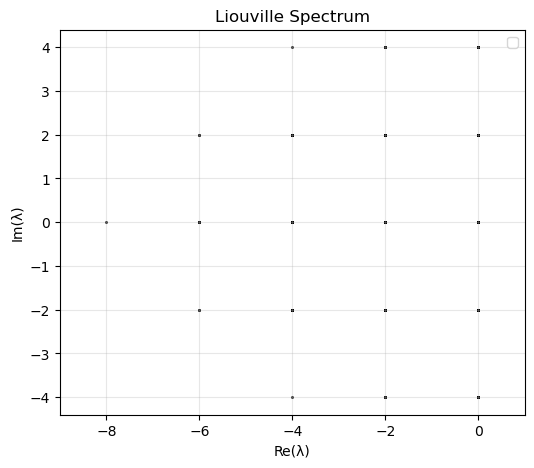

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from functools import reduce
from scipy.linalg import lu, qr, svd, null_space

# 工具函数
def tensor_product(matrices):
    """计算多个矩阵的张量积"""
    return reduce(np.kron, matrices)


def annihilation_operator(N, site):
    """
    构造N格点系统中第site个格点的湮灭算符
    
    参数:
        N: 格点总数
        site: 格点索引 (0-based)
    
    返回:
        a_i: 2^N × 2^N 矩阵
    """
    # Jordan-Wigner变换因子
    sigma_z = np.array([[1, 0], [0, -1]])
    
    # 构造弦算符 (site之前的所有格点)
    operators = []
    for j in range(N):
        if j < site:
            operators.append(sigma_z)  # 弦算符部分
        elif j == site:
            operators.append(np.array([[0, 1], [0, 0]]))  # 湮灭算符
        else:
            operators.append(np.eye(2))  # 单位矩阵
    
    # 计算Kronecker积
    result = operators[0]
    for op in operators[1:]:
        result = np.kron(result, op)
    
    return result

def creation_operator(N, site):
    """
    构造N格点系统中第site个格点的产生算符
    """
    return annihilation_operator(N, site).conj().T

def number_operator(N, site):
    """
    构造占据数算符 n_i = a_i† a_i
    """
    a = annihilation_operator(N, site)
    a_dag = creation_operator(N, site)
    return a_dag @ a


def build_hamiltonian(L, J):
    """构建最近邻跃迁哈密顿量"""
    H = np.zeros((2**L, 2**L), dtype=complex)
    # 最近邻跃迁项
    for i in range(L-1):
        H_hop = -J *(creation_operator(L, i) @ annihilation_operator(L, i+1) + creation_operator(L, i+1) @ annihilation_operator(L, i))
        H += H_hop
    

    H += -J *(creation_operator(L, L-1) @ annihilation_operator(L, 0) + creation_operator(L, 0) @ annihilation_operator(L, L-1))
    return H

def build_lindblad_operators(L, gamma):
    """构建单向跃迁Lindblad算符"""
    lindblad_ops = []
    gamma1 = 1e-2
    
    for i in range(L):
        L_op = np.sqrt(gamma) * annihilation_operator(L, i)
        lindblad_ops.append(L_op)
    
    return lindblad_ops

def build_liouville_superoperator(H, lindblad_ops, a, q):
    dim = H.shape[0]
    L_super = np.zeros((dim**2, dim**2), dtype=complex)
    I = np.eye(dim)
    L_super += -1j * (np.kron(H - 1j*a*I/2, I) - np.kron(I, (H+1j*a*I/2).T))
    for L_op in lindblad_ops:
        L_dag = L_op.conj().T
        L_super += np.kron(L_op, L_op.conj()) + q * np.kron(L_dag, L_dag.conj())
    return L_super

def compute_liouville_eigenvalues(H, lindblad_ops, a, q):
    """计算Liouville超算符的本征值"""
    L_super = build_liouville_superoperator(H, lindblad_ops, a, q)
    eigenvalues, eigenvectors = np.linalg.eig(L_super)
    return eigenvalues, eigenvectors, L_super


def plot_liouville_spectrum_vs_gamma(L, J, gamma, a, q):
    """绘制Liouville本征值谱随耗散强度的变化"""
    
    all_eigenvalues = []
    lindblad_ops = build_lindblad_operators(L, gamma)
    H = build_hamiltonian(L, J)
    eigenvalues, eigenvectors, L_super = compute_liouville_eigenvalues(H, lindblad_ops, a, q)
    all_eigenvalues.append(eigenvalues)
    re, im = np.real(eigenvalues), np.imag(eigenvalues)
    plt.scatter(re, im, alpha=1, s=1, color='black')
    plt.xlabel('Re(λ)')
    plt.ylabel('Im(λ)')
    plt.xlim(-9,1)
    
    plt.title('Liouville Spectrum')
    plt.legend()
    plt.grid(True, alpha=0.3)

    
    return eigenvalues, eigenvectors

def plot_n(eigenvalues, eigenvectors, L):
    rho, temp, r = [], [], []
    for i in range(len(eigenvectors)):
        temp.append(eigenvectors[i].reshape((2**L, 2**L)))
        if np.abs(np.trace(temp[i]) - 0) > 1e-5:
            rho.append(temp[i])
            r.append(eigenvalues[i])
            rho[-1] /= np.trace(rho[-1])
        else:
            continue
    for i in range(len(rho)):
        n = np.zeros(L)
        for j in range(L):
            n[j] = get_particle_number(rho[i], j, L)
        plt.plot(n, label='eigvals={}'.format(r[i]))
        plt.legend()
        

def main():
    """主函数"""
    # 系统参数
    L = 4 # 格点数
    J = 1  # 跃迁强度z
    gamma = 2
    a = 0
    q = 1
    # 绘制Liouville谱随耗散强度的变化
    plt.figure(figsize=(6, 5))
    print("计算Liouville本征值谱随耗散强度的变化...")

    all_eigenvalues, all_eigenvectors = plot_liouville_spectrum_vs_gamma(L, J, gamma, a, q)
    #np.savetxt('Eigenvalueq{}.txt'.format(q), all_eigenvalues)# FIg1

if __name__ == "__main__":
    main()